In [ ]:
#import all modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score


In [ ]:
#creating a dataframe from csv file
df=pd.read_csv('train.csv',usecols=['Survived','Age','Sex','Fare'])
df.sample(2)


,Survived,Sex,Age,Fare
551,0,male,27.0,26.0
618,1,female,4.0,39.0


In [ ]:
#splitting the data into x and y for training and testing
x=df.iloc[:,1:]
y=df['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)
x_train=(x_train.drop('Sex',axis=1))
x_test=(x_test.drop('Sex',axis=1))
x_train.isnull().sum()


#imputed (fill null values) all values with median
si=SimpleImputer(strategy='median')
x_train_transformed=si.fit_transform(x_train)
x_test_transformed=si.transform(x_test)
x_train_transformed








array([[29.    , 15.2458],
       [31.    , 10.5   ],
       [31.    , 37.0042],
       ...,
       [29.    ,  7.7333],
       [36.    , 17.4   ],
       [60.    , 39.    ]], shape=(712, 2))

In [ ]:
#training the model on train data and predicting on test data
clf=LogisticRegression()
clf.fit(x_train_transformed,y_train)
pred=clf.predict(x_test_transformed)
pred


array([0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0])

In [ ]:
#calculating the accuracy score 
accuracy_score(pred,y_test)
x_train_transformed[:2,:1]

array([[29.],
       [31.]])

<Axes: ylabel='Density'>

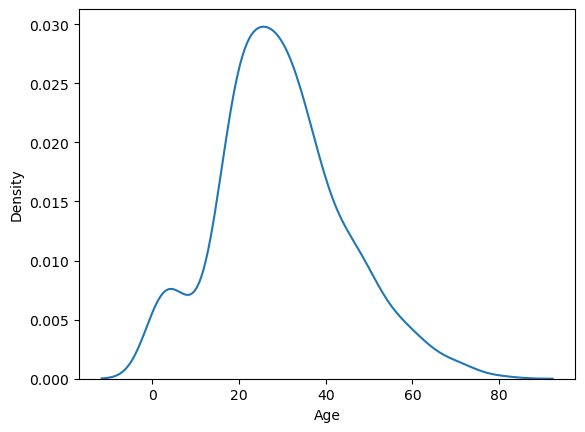

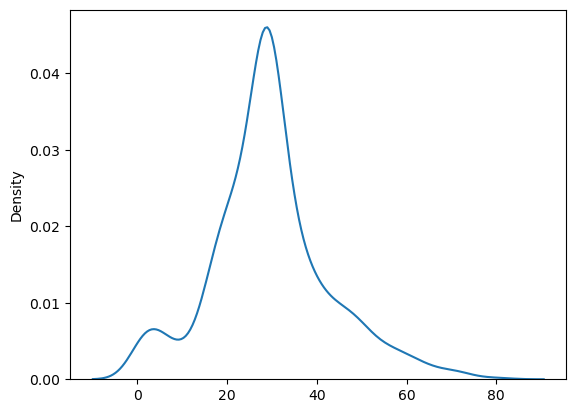

In [ ]:
#plotting the data before and after imputation
plt.figure(121)
sns.kdeplot(x_train['Age'])

plt.figure(122)
sns.kdeplot(x_train_transformed[:,0])